# Network summary — Dataset 2 (static synthetic interbank network, 1 444 banks)

Structural characteristics of the single static network: number of nodes/edges, density,
average degree, reciprocity, clustering coefficient, assortativity, connected components,
average path length and diameter.

Outputs (`src/data/network_summary/`):
- `dataset_2_summary.csv` — one column of metrics
- `dataset_2_layout.csv` — spring-layout coordinates used for the graph figure

The combined table + three-graph figure lives in `../network_summary_table.ipynb`.

In [1]:
import sys
from pathlib import Path

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path

OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'network_summary'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB_DIR = PROJECT_ROOT / 'src' / 'notebooks' / '00_notes' / 'dataset_2'

DATASET_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_2'

## Load the network (weighted adjacency matrix in `network.xlsx`)

In [2]:
matrix = pd.read_excel(DATASET_DIR / 'network.xlsx', index_col=0)
edges = matrix.stack().reset_index()
edges.columns = ['source_bank', 'target_bank', 'weight']
edges = edges[edges['weight'] != 0].copy()

G = nx.DiGraph()
G.add_nodes_from(matrix.index)
G.add_edges_from(edges[['source_bank', 'target_bank']].itertuples(index=False, name=None))
print(f'{G.number_of_nodes()} banks, {G.number_of_edges()} directed edges')

1444 banks, 2893 directed edges


## Summary metrics

Clustering, assortativity, path length and diameter use the undirected projection;
path length and diameter are computed on the largest connected component (LCC).

In [3]:
def network_summary(G: nx.DiGraph) -> dict:
    """Structural summary of a directed network.

    Clustering, assortativity, path length and diameter are computed on the
    undirected projection; path length and diameter on its largest connected
    component (BFS distances via scipy, C speed).
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    U = nx.Graph(G)  # undirected projection (reciprocal pairs collapse)

    components = list(nx.connected_components(U))
    lcc_nodes = max(components, key=len)
    U_lcc = U.subgraph(lcc_nodes)

    A = nx.to_scipy_sparse_array(U_lcc, format='csr', weight=None)
    D = shortest_path(A, method='D', unweighted=True, directed=False)
    finite = D[np.isfinite(D) & (D > 0)]

    degrees = np.array([d for _, d in G.degree()])  # in + out

    return {
        'n_nodes': n,
        'n_edges': m,
        'density': nx.density(G),
        'avg_degree': degrees.mean(),
        'max_degree': degrees.max(),
        'reciprocity': nx.reciprocity(G),
        'avg_clustering': nx.average_clustering(U),
        'degree_assortativity': nx.degree_assortativity_coefficient(U),
        'n_components': len(components),
        'lcc_size': len(lcc_nodes),
        'lcc_share': len(lcc_nodes) / n,
        'avg_path_length': finite.mean(),
        'diameter': finite.max(),
    }


In [4]:
summary = pd.DataFrame({'value': pd.Series(network_summary(G))})
summary.index.name = 'metric'
summary.to_csv(OUT_DIR / 'dataset_2_summary.csv')
summary

,value
metric,
n_nodes,1444.000000
n_edges,2893.000000
density,0.001388
avg_degree,4.006925
max_degree,228.000000
reciprocity,0.017974
avg_clustering,0.085731
degree_assortativity,-0.279260
n_components,1.000000


## Graph figure

Spring layout of the largest connected component. Coordinates are saved for reuse.

In [5]:
U = nx.Graph(G)
lcc = max(nx.connected_components(U), key=len)
U_lcc = U.subgraph(lcc)

pos = nx.spring_layout(U_lcc, seed=42, iterations=50)
pd.DataFrame([(n, x, y) for n, (x, y) in pos.items()], columns=['node', 'x', 'y']) \
    .to_csv(OUT_DIR / 'dataset_2_layout.csv', index=False)
print(f'layout: {len(pos)} nodes')

layout: 1444 nodes


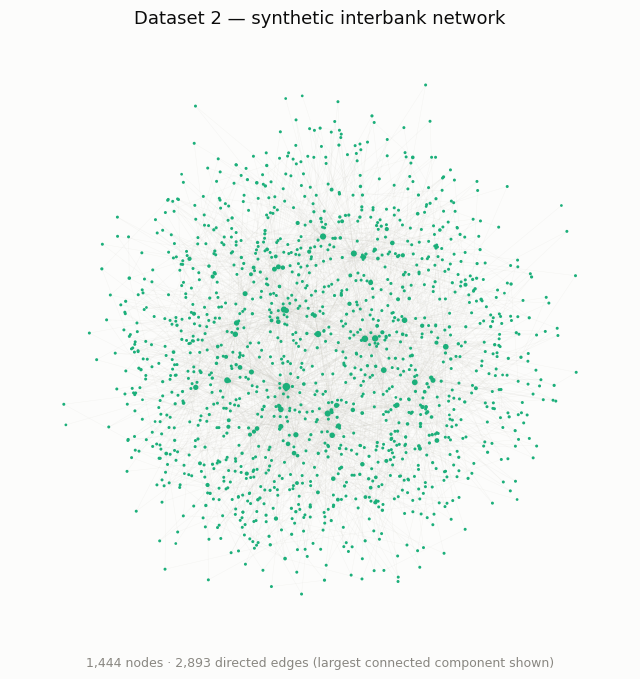

In [6]:
# Figure style (thesis palette)
SURFACE, INK, MUTED, EDGE_COLOR = '#fcfcfb', '#0b0b0b', '#898781', '#c3c2b7'

def draw_network(U_lcc, pos, color, title, subtitle, out_path, ax=None):
    deg = dict(U_lcc.degree())
    s = np.array([deg[n] for n in U_lcc.nodes()], dtype=float)
    sizes = 2 + 28 * np.sqrt(s / s.max())

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    nx.draw_networkx_edges(U_lcc, pos, ax=ax, edge_color=EDGE_COLOR, alpha=0.15, width=0.3)
    nx.draw_networkx_nodes(U_lcc, pos, ax=ax, node_color=color, node_size=sizes, linewidths=0)
    ax.set_title(title, color=INK, fontsize=13)
    ax.text(0.5, -0.03, subtitle, transform=ax.transAxes, ha='center', color=MUTED, fontsize=9)
    ax.set_axis_off()
    if own_fig:
        fig.savefig(out_path, dpi=200, facecolor=SURFACE, bbox_inches='tight')
        plt.show()

draw_network(
    U_lcc, pos, color='#1baf7a',
    title='Dataset 2 — synthetic interbank network',
    subtitle=(f'{U_lcc.number_of_nodes():,} nodes · {G.number_of_edges():,} directed edges '
              f'(largest connected component shown)'),
    out_path=NB_DIR / 'dataset_2_graph.png',
)